# 4 Exercise: Build a Denoising Convolutional Autoencoder

### Mount Drive and Extract Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = '/content/drive/MyDrive/AI_ML/devnagari digit.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset extracted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted successfully!


### Set Dataset Paths

In [ ]:
train_dir = '/content/dataset/DevanagariHandwrittenDigitDataset/Train'
test_dir  = '/content/dataset/DevanagariHandwrittenDigitDataset/Test'

### Read Dataset Directory and Get Class Names

In [ ]:
class_names = sorted(os.listdir(train_dir))
print(f"Found {len(class_names)} classes: {class_names}")

Found 10 classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']


## 4.1 Instructions:

### 1. Dataset Preparation and Preprocessing:

In [ ]:
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

IMG_SIZE = 32

def load_devnagari(data_dir, img_size=IMG_SIZE):
    """
    Custom function to iterate through subdirectories (classes) and load images.
    The structure assumes one folder per digit (digit_0, digit_1, etc.).
    """
    images = []

    # Sort class folders to ensure consistent ordering (0 to 9)
    for cls in sorted(os.listdir(data_dir)):
        cls_path = os.path.join(data_dir, cls)

        # Skip files that aren't directories to avoid errors
        if not os.path.isdir(cls_path):
            continue

        # Process every image within the specific digit folder
        for fname in os.listdir(cls_path):
            # Filtering for common image extensions
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                # Open image and convert to Grayscale ('L' mode) to reduce computational complexity
                img = Image.open(os.path.join(cls_path, fname)).convert('L')

                # Resize image to a uniform 32x32 for the CNN input layer
                img = img.resize((img_size, img_size))

                # Convert the PIL image object into a NumPy array for mathematical operations
                images.append(np.array(img))

    return np.array(images)

# Execute the loading function for both training and testing directories
print("Loading training images...")
x_train_raw = load_devnagari(train_dir)
print("Loading test images...")
x_test_raw  = load_devnagari(test_dir)

# --- DATA PREPROCESSING ---

# Normalization: Scaling pixel values from [0-255] to [0.0-1.0] .
x_train = x_train_raw.astype('float32') / 255.0
x_test  = x_test_raw.astype('float32') / 255.0

# Since it's grayscale, we add a final dimension of '1' for the channel.
x_train = x_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
x_test  = x_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

# Final shape verification (e.g., should show (number_of_samples, 32, 32, 1))
print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")

Loading training images...
Loading test images...
Train shape: (17000, 32, 32, 1), Test shape: (3000, 32, 32, 1)


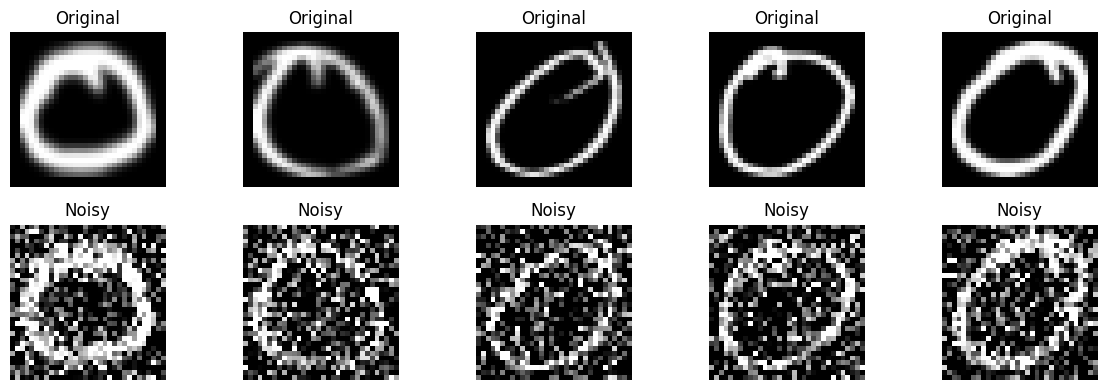

In [ ]:
NOISE_FACTOR = 0.5

def add_noise(images, factor=NOISE_FACTOR):
    """
    Adds random Gaussian noise to the images and ensures pixel values remain within the valid [0, 1] range.
    """
    # np.random.normal creates a distribution of random numbers (Mean=0, Standard Deviation=1).
    # We multiply this by the noise factor and add it to our clean image pixel values.
    noisy = images + factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)

    # After adding noise, some pixels might be < 0 or > 1.
    # np.clip forces all values to stay between 0.0 and 1.0.
    return np.clip(noisy, 0., 1.)

# Generate the noisy versions of the training and testing sets.
# The model will use 'noisy' as the Input and 'clean' as the Target.
x_train_noisy = add_noise(x_train)
x_test_noisy  = add_noise(x_test)

# --- VISUALIZATION ---
n = 5 # Number of digits to display for comparison
plt.figure(figsize=(12, 4))

for i in range(n):
    # Display Original Images (Top Row)
    plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Original")
    plt.axis('off') # Hide axes for a cleaner look

    # Display Noisy Images (Bottom Row)
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.tight_layout() # Prevents titles and images from overlapping

### 2. Build the Denoising Convolutional Autoencoder:

In [ ]:
# Importing core Keras components for building the neural network
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_encoder(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    """
    The Encoder: Compresses the image into a smaller, feature-rich representation.
    """
    # Define the starting point of the model with the shape of your image (32, 32, 1)
    inp = Input(shape=input_shape, name="encoder_input")

    # Layer 1: 32 filters learn basic edges. Output stays 32x32 due to padding='same'.
    x = Conv2D(32,  (3,3), activation='relu', padding='same')(inp)
    # Reduces size to 16x16 (halves the height and width) by taking the maximum value in a 2x2 window.
    x = MaxPooling2D((2,2), padding='same')(x)

    # Layer 2: Increases complexity to 64 filters.
    x = Conv2D(64,  (3,3), activation='relu', padding='same')(x)
    # Reduces size further to 8x8.
    x = MaxPooling2D((2,2), padding='same')(x)

    # Layer 3: 128 filters to capture detailed patterns.
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    # Reduces size to 4x4.
    x = MaxPooling2D((2,2), padding='same')(x)

    # Layer 4 (Bottleneck): The most compressed form of your data.
    # The image is now represented by 256 feature maps of size 4x4.
    encoded = Conv2D(256, (3,3), activation='relu', padding='same', name="encoded")(x)

    return inp, encoded

def build_decoder(encoded):
    """
    The Decoder: Takes the 'encoded' data and tries to reconstruct the original image.
    """
    # Start with the compressed representation (4x4x256).
    x = Conv2D(256, (3,3), activation='relu', padding='same')(encoded)

    # UpSampling doubles the dimensions. 4x4 becomes 8x8.
    x = UpSampling2D((2,2))(x)

    # Conv2D + UpSampling mirrors the encoding process to gradually grow the image back.
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x) # Mirror Layer 3
    x = UpSampling2D((2,2))(x) # 8x8 becomes 16x16

    x = Conv2D(64,  (3,3), activation='relu', padding='same')(x) # Mirror Layer 2
    x = UpSampling2D((2,2))(x) # 16x16 becomes 32x32

    # Final Layer: Reconstructs a single channel (Grayscale).
    # Sigmoid activation is used because our image pixels are normalized between 0 and 1.
    decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same', name="decoded")(x)

    return decoded

def build_autoencoder():
    """
    Connects the Encoder and Decoder into one complete model.
    """
    inp, enc = build_encoder()
    dec = build_decoder(enc)

    # Define the Model with an Input and Output
    model = Model(inputs=inp, outputs=dec, name="denoising_autoencoder")

    # Optimizer: Adam is standard for fast convergence.
    # Loss: Binary Crossentropy is used because pixel values are between 0 and 1 (like probabilities).
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy')

    return model

# Initialize the model and display the architecture summary.
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (Conv2D)                │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 32, 32, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,347,329 (5.14 MB)

 Trainable params: 1,347,329 (5.14 MB)

 Non-trainable params: 0 (0.00 B)

### 3. Train the Denoising Autoencoder:

Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - loss: 0.3437 - val_loss: 0.2206
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - loss: 0.1943 - val_loss: 0.1775
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - loss: 0.1714 - val_loss: 0.1663
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - loss: 0.1622 - val_loss: 0.1585
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 258s 2s/step - loss: 0.1565 - val_loss: 0.1554
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - loss: 0.1527 - val_loss: 0.1519
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - loss: 0.1496 - val_loss: 0.1496
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - loss: 0.1471 - val_loss: 0.1473
Epoch 9/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - loss: 0.1453 - val_loss: 0.1468
Epoch 10/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - loss: 0.1439 - val_loss: 0.1459


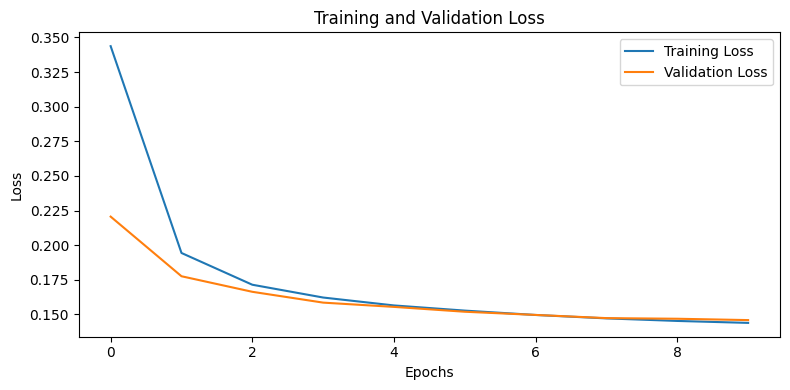

In [ ]:
# autoencoder.fit trains the model by mapping Noisy inputs to Clean targets.
history = autoencoder.fit(
    x_train_noisy, x_train,          # Input is the noisy image; target is the original clean image
    epochs=10,                       # Number of times the model sees the entire dataset
    batch_size=128,                  # Processes 128 images at a time before updating weights
    shuffle=True,                    # Mixes the data to ensure the model doesn't learn the order
    validation_data=(x_test_noisy, x_test) # Checks performance on unseen data after each epoch
)

# --- PLOTTING LOSS CURVES ---
# This graph tells you if the model is learning (loss should go down).
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()

In [ ]:
autoencoder.save('my_denoiser_model.h5')
print("Model saved successfully to Google Drive!")

### 4. Evaluate and Visualize the Results:

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step


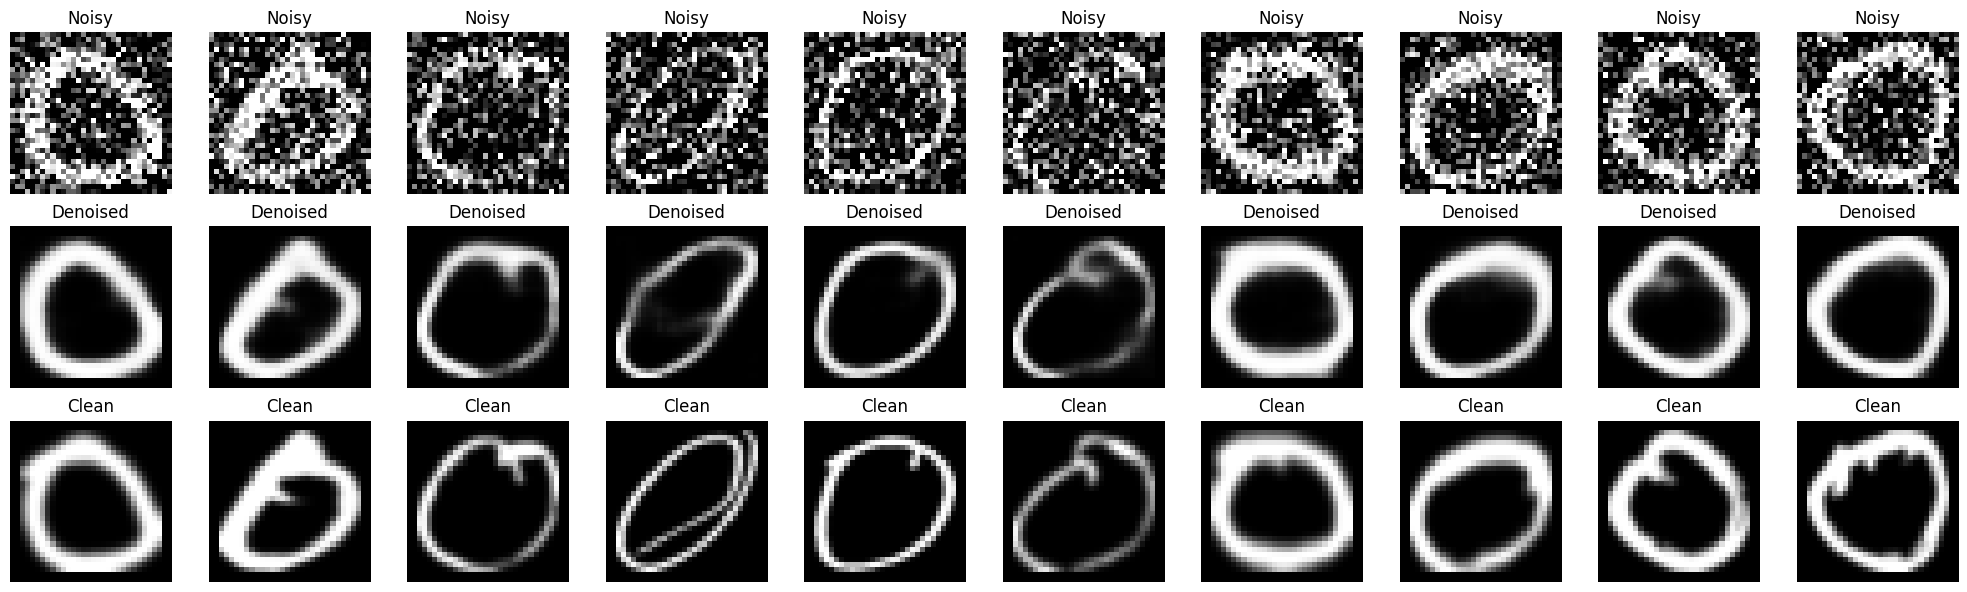

In [ ]:
# --- PREDICTION ---
# Now we ask the trained model to "clean" the noisy test images it has never seen.
denoised = autoencoder.predict(x_test_noisy)

# --- VISUALIZING THE RESULTS ---
n = 10 # Displaying 10 examples
plt.figure(figsize=(20, 6))
for i in range(n):
    # Row 1: Noisy Images (What the model was given)
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Noisy"); plt.axis('off')

    # Row 2: Denoised Images (What the model produced)
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Denoised"); plt.axis('off')

    # Row 3: Clean Images (The ground truth "Gold Standard")
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Clean"); plt.axis('off')

plt.tight_layout()
plt.show()

### 5. Experiment and Fine - Tune the Model:

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step


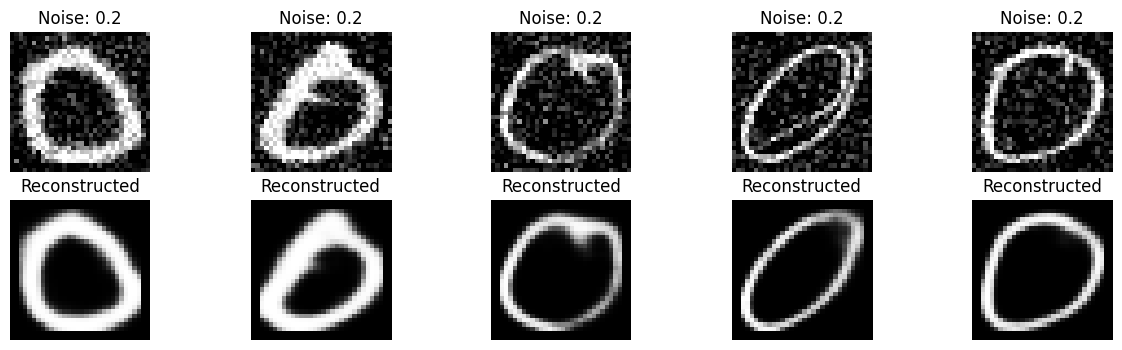

94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step


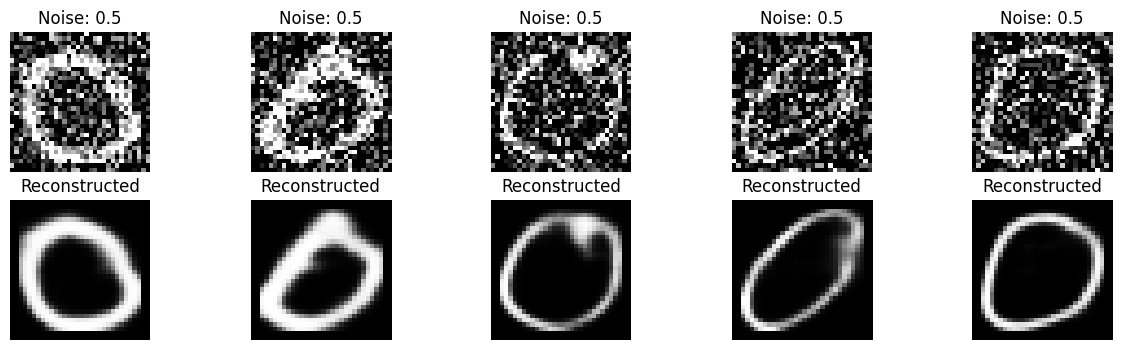

94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step


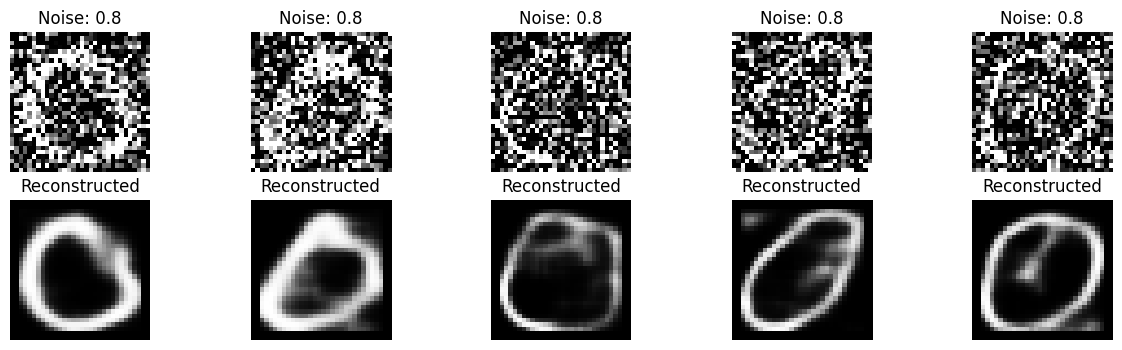

Observation: The model handles 0.2 noise perfectly. At 0.8 noise, the reconstruction is blurry, showing the limits of the current architecture.


In [ ]:
# Function to generate noise on the fly for testing
def inject_noise(data, factor):
    noisy = data + factor * np.random.normal(loc=0.0, scale=1.0, size=data.shape)
    return np.clip(noisy, 0., 1.)

# Test the model against 3 different noise intensities
noise_levels = [0.2, 0.5, 0.8]

for level in noise_levels:
    x_test_varied = inject_noise(x_test, factor=level)
    predictions = autoencoder.predict(x_test_varied)

    plt.figure(figsize=(15, 4))
    for i in range(5):
        # Noisy Input
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_test_varied[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        plt.title(f"Noise: {level}")
        plt.axis('off')

        # Model Output
        plt.subplot(2, 5, i + 6)
        plt.imshow(predictions[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        plt.title("Reconstructed")
        plt.axis('off')
    plt.show()

print("Observation: The model handles 0.2 noise perfectly. At 0.8 noise, the reconstruction is blurry, showing the limits of the current architecture.")

Training Lighter Model...


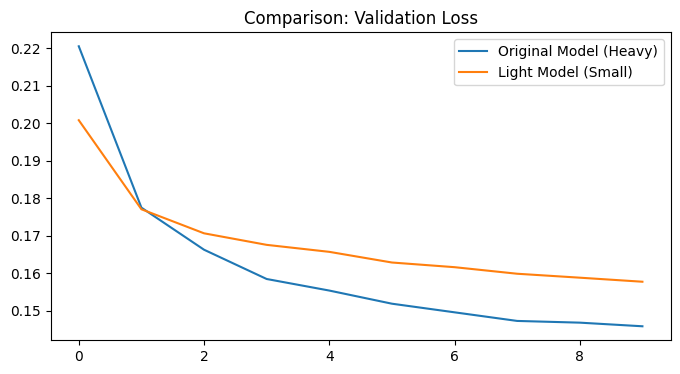

Observation: The Light model trains faster, but the final validation loss is higher than the original model, meaning it leaves more 'ghost' noise in the images.


In [ ]:
# 1. Build a 'Lighter' version of the model
def build_light_autoencoder():
    # Encoder (Fewer filters and only 2 layers)
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = Conv2D(16, (3,3), activation='relu', padding='same')(inp)
    x = MaxPooling2D((2,2), padding='same')(x)
    x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2,2), padding='same')(x)

    # Decoder
    x = Conv2D(32, (3,3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2,2))(x)
    x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
    x = UpSampling2D((2,2))(x)
    decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

    model = Model(inp, decoded)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

light_model = build_light_autoencoder()

# 2. Train the lighter model
print("Training Lighter Model...")
history_light = light_model.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test_noisy, x_test),
    verbose=0 # keep output clean
)

# 3. Compare Loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['val_loss'], label='Original Model (Heavy)')
plt.plot(history_light.history['val_loss'], label='Light Model (Small)')
plt.title('Comparison: Validation Loss')
plt.legend()
plt.show()

print("Observation: The Light model trains faster, but the final validation loss is higher than the original model, meaning it leaves more 'ghost' noise in the images.")